
# Spotify Music Segmentation Using Unsupervised Machine Learning

## Project Overview
This project applies K-Means, Hierarchical Clustering, and DBSCAN to discover natural groups of songs based on Spotify audio features.

### Objectives
- Data Loading and Understanding
- Exploratory Data Analysis (EDA)
- Data Cleaning & Preprocessing
- Feature Selection & Scaling
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN Clustering
- Cluster Evaluation
- PCA Visualization
- Pipeline Development
- Model Export
- Streamlit Deployment


In [24]:

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import scipy.cluster.hierarchy as sch
import joblib

pd.set_option('display.max_columns', None)


## 1. Data Loading

In [25]:

df = pd.read_csv("Spotify dataset.csv")

df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [26]:
print("Rows, Columns:", df.shape)

Rows, Columns: (114000, 21)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


## 2. Data Quality Checks

In [29]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [30]:
df=df.dropna(axis=1)

In [31]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


## 3. Data Cleaning

In [32]:
# drop unneccessary columns
drop_cols = [
    'track_id',
    'track_name',
    'album_name',
    'artists',
    'track_genre'
]

df = df.drop(columns=drop_cols, errors='ignore')
df.head()


,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


## 4. Exploratory Data Analysis

### columns distribution

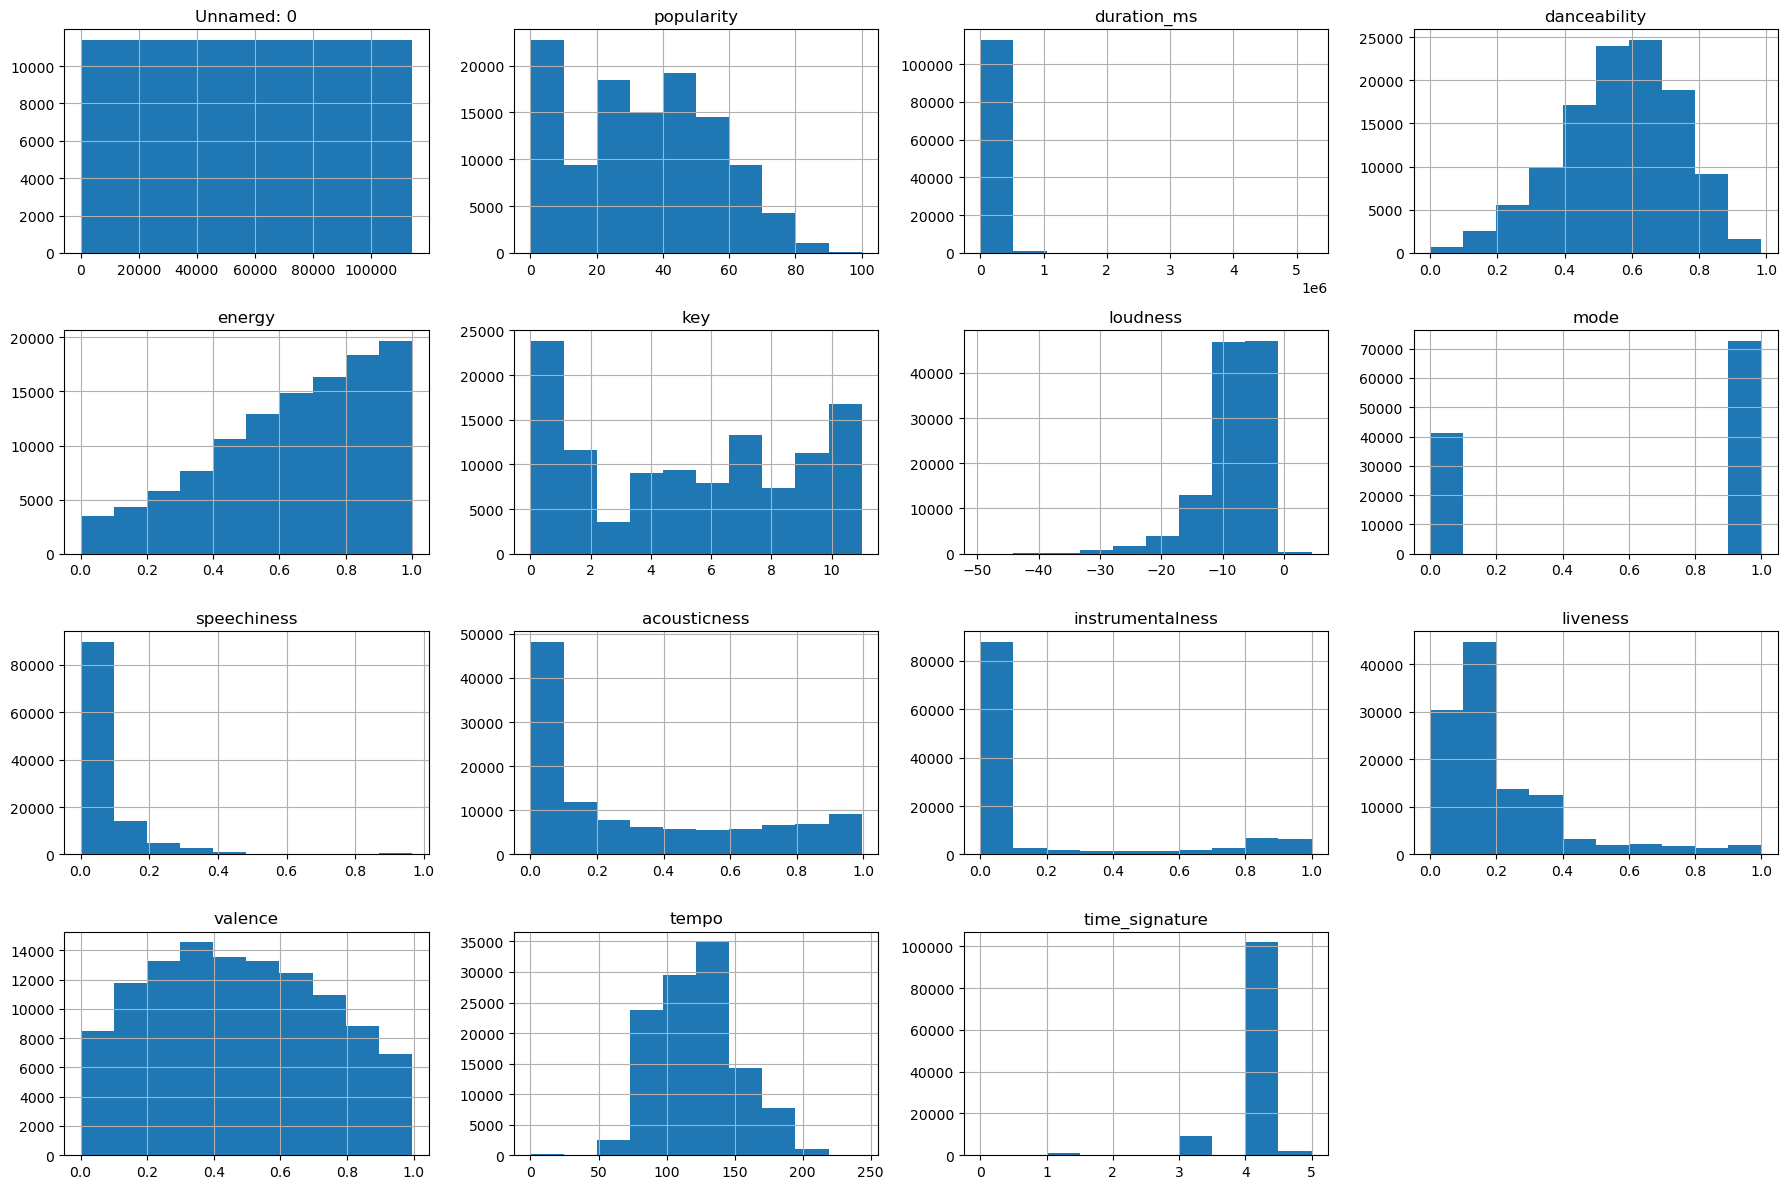

In [33]:
df.hist(figsize=(18,12))
plt.tight_layout()
plt.show()

### Correlation heatmap

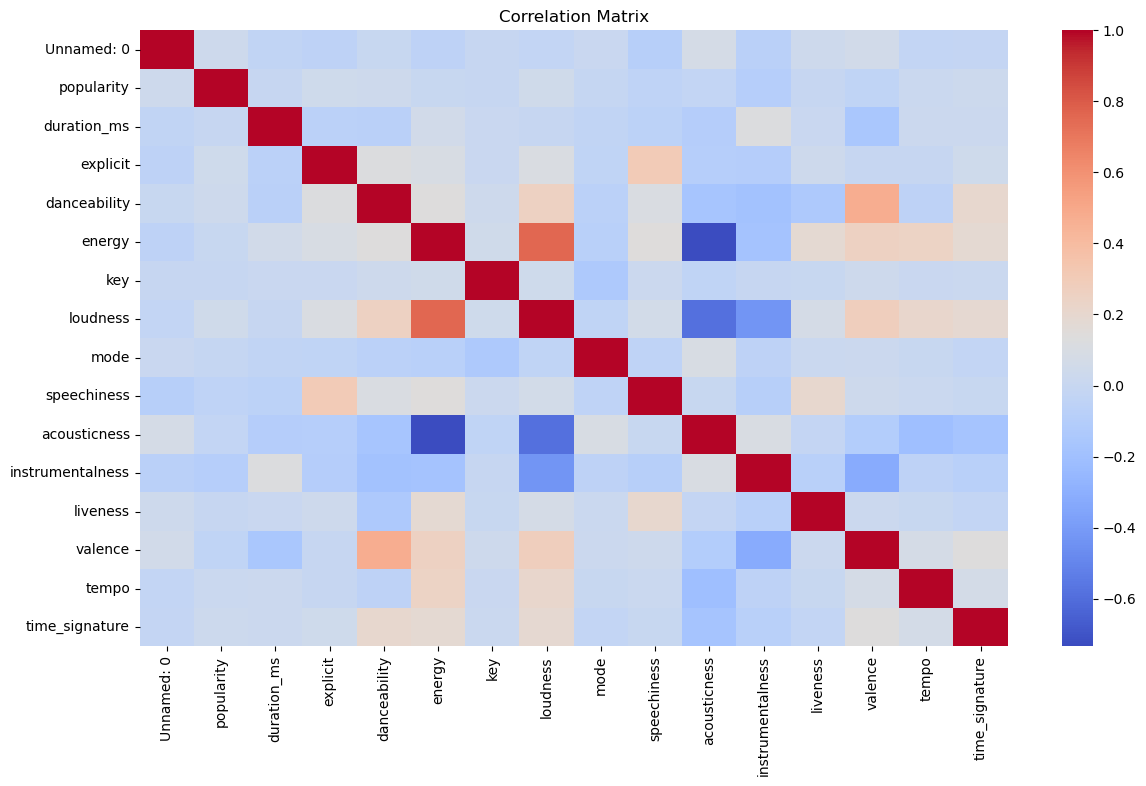

In [34]:

plt.figure(figsize=(14,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=False,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


### Boxplot

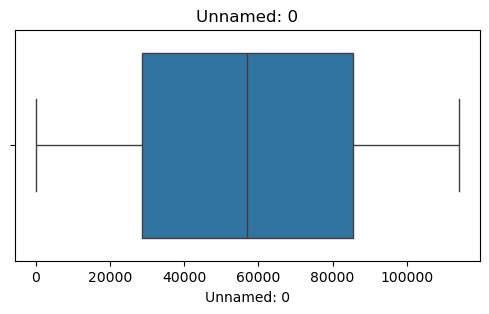

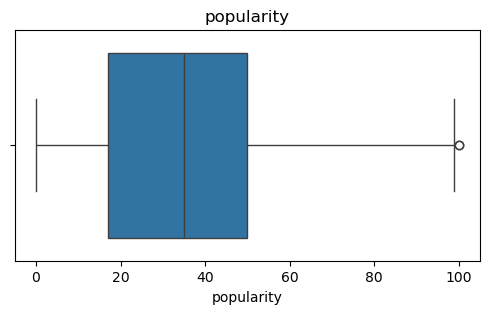

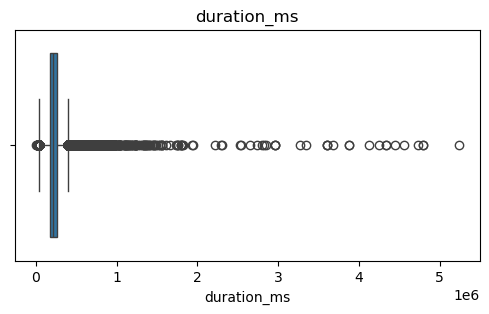

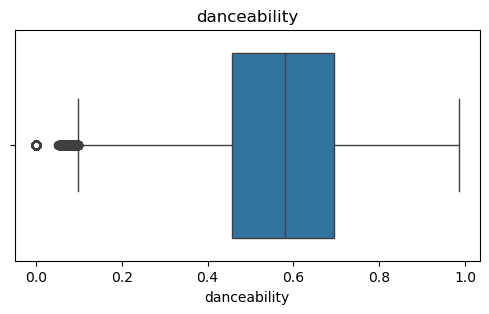

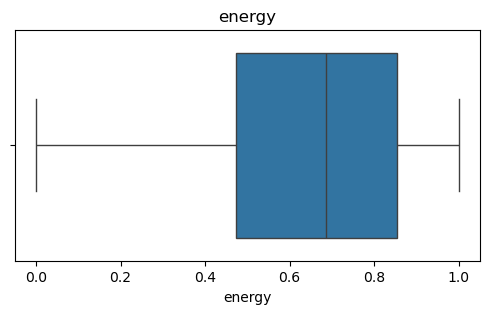

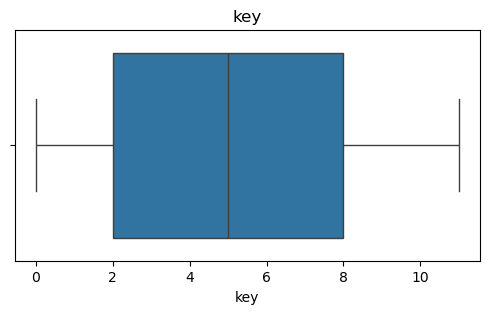

In [35]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols[:6]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


### Remove Outliers Using IQR Method

In [36]:
# For danceability
Q1 = df['danceability'].quantile(0.25)
Q3 = df['danceability'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['danceability'] >= lower) &
        (df['danceability'] <= upper)]

In [37]:
# For duration_ms
Q1 = df['duration_ms'].quantile(0.25)
Q3 = df['duration_ms'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['duration_ms'] >= lower) &
        (df['duration_ms'] <= upper)]

In [38]:
# Remove Outliers from Both Columns Together
for col in ['danceability', 'duration_ms']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("New Shape:", df.shape)

New Shape: (106017, 16)


### Insight
Outliers in the danceability and duration_ms features were identified using the Interquartile Range (IQR) method. Records lying outside the lower and upper bounds (Q1 − 1.5×IQR and Q3 + 1.5×IQR) were removed to improve clustering performance and reduce the influence of extreme values.

## 5. Feature Selection

In [39]:
selected_features = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[selected_features]

print(X.shape)
X.head()


(106017, 11)


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,73,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,55,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,57,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,71,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,82,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


## 6. Feature Scaling

In [40]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape


(106017, 11)

## 7. Elbow Method

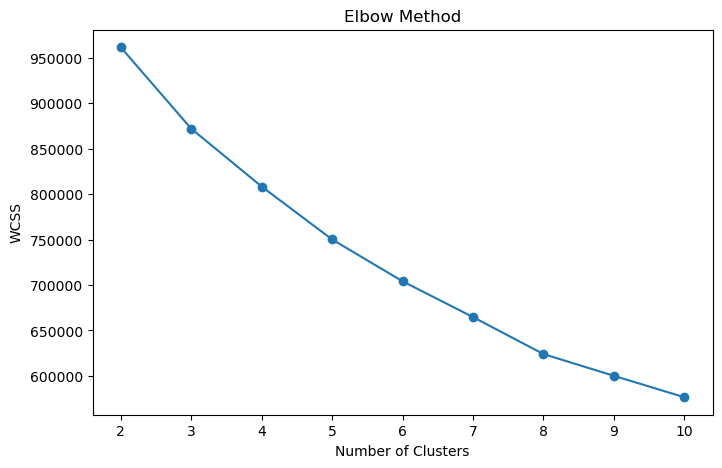

In [41]:

wcss = []

for i in range(2,11):
    
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### Insight
The Elbow Method was used to determine the optimal number of clusters. The WCSS value decreased significantly until K=5 and then began to flatten. Therefore, K=5 was selected as the optimal number of clusters for K-Means clustering.

## 8. K-Means Clustering

In [42]:

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print(df['KMeans_Cluster'].value_counts())

KMeans_Cluster
4    38458
3    30180
0    22389
1     7651
2     7339
Name: count, dtype: int64


### K-Means Evaluation

In [43]:
# Silhouette Score 
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

# Davies-Bouldin Index
kmeans_dbi = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Index:", kmeans_dbi)


Silhouette Score: 0.14043519873766122
Davies-Bouldin Index: 1.8912724156822638


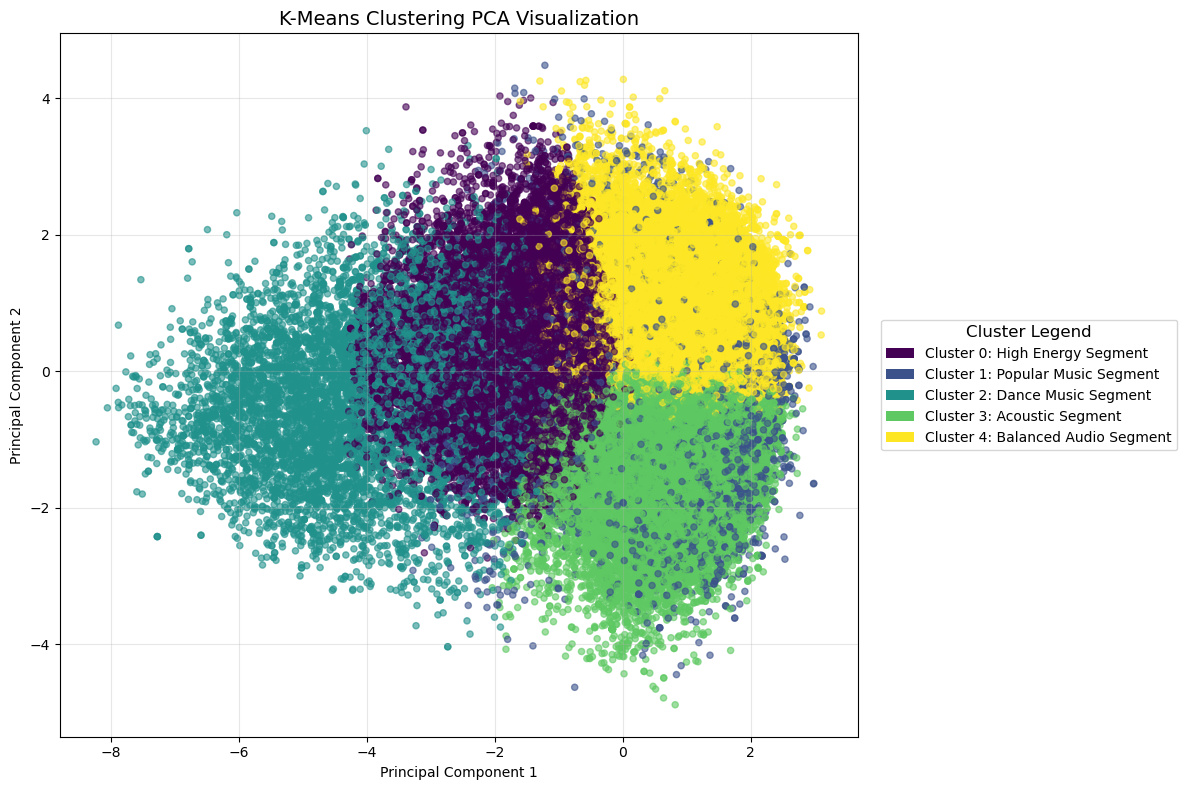

In [44]:
# K-Means PCA Visualization with Cluster Legend

from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

# Add Cluster Labels
pca_df['Cluster'] = kmeans_labels

# Business Style Cluster Names
cluster_names = {
    0: "High Energy Segment",
    1: "Popular Music Segment",
    2: "Dance Music Segment",
    3: "Acoustic Segment",
    4: "Balanced Audio Segment"
}

# Plot
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=20
)

# Create Legend Colors
unique_clusters = sorted(pca_df['Cluster'].unique())

colors = scatter.cmap(
    scatter.norm(unique_clusters)
)

# Create Legend Items
legend_elements = [
    Patch(
        facecolor=colors[i],
        label=f"Cluster {cluster}: {cluster_names[cluster]}"
    )
    for i, cluster in enumerate(unique_clusters)
]

# Place Legend on Right Side
plt.legend(
    handles=legend_elements,
    title="Cluster Legend",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    title_fontsize=12
)

plt.title("K-Means Clustering PCA Visualization", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Hierarchical Clustering

In [45]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.utils import resample

# Take a sample of 5000 rows
X_sample = resample(
    X_scaled,
    n_samples=3000,
    random_state=42
)
print(X_sample.shape)


(3000, 11)


In [46]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical.fit_predict(X_sample)


### Hierarchical Evaluation

In [47]:
# Silhouette Score
hier_silhouette = silhouette_score(
    X_sample,
    hierarchical_labels
)
# Davies-Bouldin Index
hier_dbi = davies_bouldin_score(
    X_sample,
    hierarchical_labels
)

print("Silhouette Score:", hier_silhouette)
print("Davies-Bouldin Index:", hier_dbi)


Silhouette Score: 0.10966761423344486
Davies-Bouldin Index: 2.078286236323161


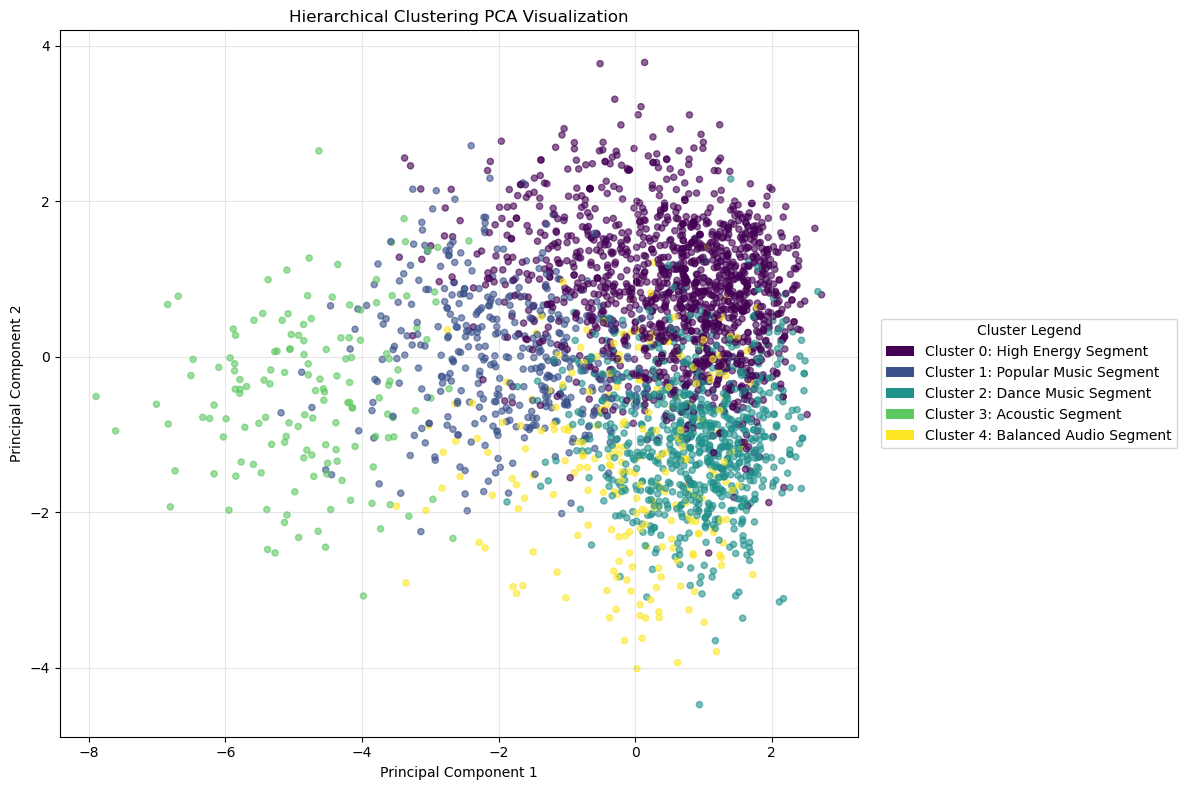

In [48]:
# K-Means PCA Visualization with Cluster Legend
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

# PCA
pca_hier = PCA(n_components=2)

pca_hier_data = pca_hier.fit_transform(X_sample)

# DataFrame
pca_hier_df = pd.DataFrame(
    pca_hier_data,
    columns=['PCA1', 'PCA2']
)

pca_hier_df['Cluster'] = hierarchical_labels

# Cluster Names
cluster_names = {
    0: "High Energy Segment",
    1: "Popular Music Segment",
    2: "Dance Music Segment",
    3: "Acoustic Segment",
    4: "Balanced Audio Segment"
}

# Plot
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_hier_df['PCA1'],
    pca_hier_df['PCA2'],
    c=pca_hier_df['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=20
)

# Legend
unique_clusters = sorted(pca_hier_df['Cluster'].unique())

colors = scatter.cmap(
    scatter.norm(unique_clusters)
)

legend_elements = [
    Patch(
        facecolor=colors[i],
        label=f"Cluster {cluster}: {cluster_names[cluster]}"
    )
    for i, cluster in enumerate(unique_clusters)
]

plt.legend(
    handles=legend_elements,
    title="Cluster Legend",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.title("Hierarchical Clustering PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
  

## 10. DBSCAN

In [49]:

dbscan = DBSCAN(
    eps=1.5,
    min_samples=20
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)
df['DBSCAN_Cluster'] = dbscan_labels


### DBSCAN Evaluation

In [50]:
dbscan_silhouette = silhouette_score(
    X_scaled,
    dbscan_labels
)

dbscan_dbi = davies_bouldin_score(
    X_scaled,
    dbscan_labels
)

print("Silhouette Score:", dbscan_silhouette)
print("Davies-Bouldin Index:", dbscan_dbi)

Silhouette Score: 0.2364956663124624
Davies-Bouldin Index: 2.1751655185774554


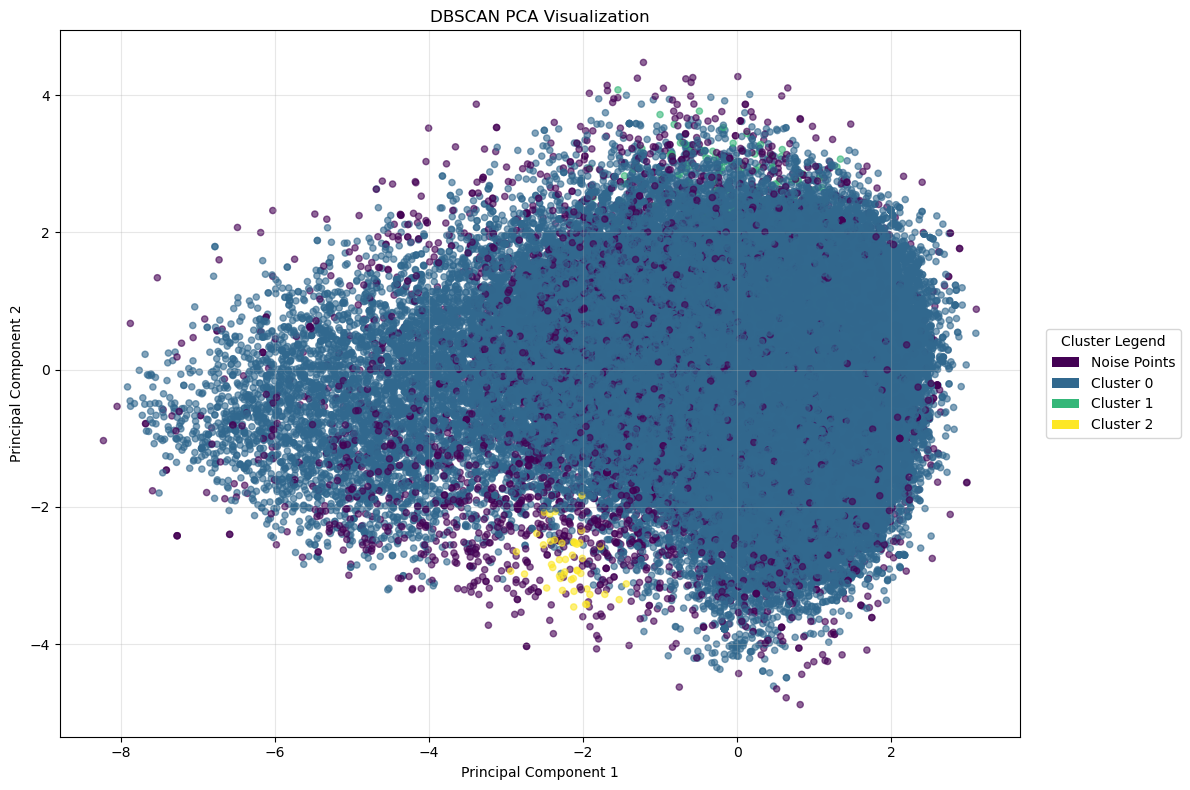

In [51]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

# PCA
pca_db = PCA(n_components=2)

pca_db_data = pca_db.fit_transform(X_scaled)

# DataFrame
pca_db_df = pd.DataFrame(
    pca_db_data,
    columns=['PCA1', 'PCA2']
)

pca_db_df['Cluster'] = dbscan_labels

# Plot
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_db_df['PCA1'],
    pca_db_df['PCA2'],
    c=pca_db_df['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=20
)

# Unique Clusters
unique_clusters = sorted(pca_db_df['Cluster'].unique())

colors = scatter.cmap(
    scatter.norm(unique_clusters)
)

# Legend
legend_elements = []

for i, cluster in enumerate(unique_clusters):

    if cluster == -1:
        label = "Noise Points"
    else:
        label = f"Cluster {cluster}"

    legend_elements.append(
        Patch(
            facecolor=colors[i],
            label=label
        )
    )

plt.legend(
    handles=legend_elements,
    title="Cluster Legend",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.title("DBSCAN PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
pd.Series(dbscan_labels).value_counts()

 0    99949
-1     5506
 1      517
 2       45
Name: count, dtype: int64

#### Interpretation of Clustering Algorithms
### K-Means Clustering
- Created balanced and well-distributed clusters.
- Grouped songs with similar audio characteristics.
- Achieved the lowest Davies-Bouldin Index (1.89).
- Selected as the final clustering model.

### Hierarchical Clustering
- Formed meaningful clusters based on similarity.
- Showed slightly lower cluster separation than K-Means.
- Computationally expensive for large datasets.
- Useful for understanding cluster relationships.

### DBSCAN
- Identified one large cluster and several small clusters.
- Detected 5,506 noise/outlier songs.
- Achieved the highest Silhouette Score (0.2365).
- Produced highly imbalanced clusters, making interpretation difficult.

## 11. Model Comparison

In [52]:
results = pd.DataFrame({
    "Algorithm":[
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score":[
        kmeans_silhouette,
        hier_silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Index":[
        kmeans_dbi,
        hier_dbi,
        dbscan_dbi
    ]
})

print(results)

      Algorithm  Silhouette Score  Davies-Bouldin Index
0       K-Means          0.140435              1.891272
1  Hierarchical          0.109668              2.078286
2        DBSCAN          0.236496              2.175166


#### Conclusion
- K-Means performed best overall and was selected as the final model.
- Hierarchical Clustering provided reasonable results but was less efficient.
- DBSCAN was not suitable because the dataset lacked strong density-based separations.

#### Cluster Profiling

Cluster profiling helps us understand the characteristics of each cluster by analyzing the average values of the features within each group.

In [59]:
cluster_profile = df.groupby('KMeans_Cluster').mean(numeric_only=True)

cluster_profile

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,61776.810711,34.309572,209267.600652,0.041851,0.534013,0.376767,5.111349,-10.644657,0.727679,0.053985,0.680507,0.026567,0.159373,0.395546,112.944391,3.824065,-0.034705
1,59848.133577,34.499804,213891.190041,0.139720,0.539759,0.753635,5.351980,-7.314456,0.655993,0.189413,0.339008,0.057643,0.736229,0.515778,121.270302,3.901320,-0.141681
2,55501.018531,30.094700,183002.893173,0.004088,0.426358,0.224190,4.998774,-19.327816,0.631421,0.055986,0.808409,0.807759,0.152619,0.235327,108.529092,3.744243,-0.178090
3,52704.823393,36.202087,237524.840358,0.086945,0.483194,0.811102,5.358284,-5.749775,0.610769,0.077912,0.069980,0.182919,0.191878,0.343262,136.348195,3.934062,-0.031942
4,58021.504342,31.697384,201133.832285,0.124369,0.698906,0.727972,5.443965,-6.329724,0.609028,0.092750,0.200585,0.043059,0.166140,0.692050,119.895359,3.981382,-0.019944


### Cluster Distribution

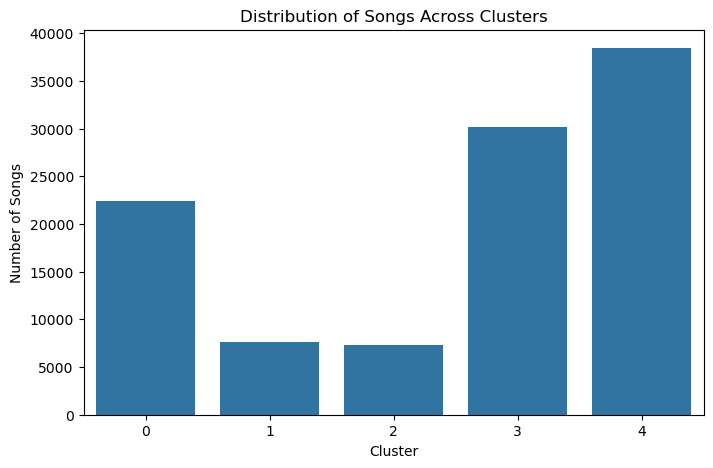

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='KMeans_Cluster',
    data=df
)

plt.title("Distribution of Songs Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")

plt.show()

#### Interpretation
- Cluster 0: Represents songs with similar audio characteristics grouped together.
- Cluster 1: Contains songs with distinct feature patterns compared to other clusters.
- Cluster 2: Shows different levels of energy, danceability, and popularity.
- Cluster 3: Represents another unique segment of songs.
- Cluster 4: Contains songs with balanced feature values.

### Pipeline Development

In [62]:
from sklearn.pipeline import Pipeline

# Create Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    ))
])

# Train the Pipeline
pipeline.fit(X)

# Verify Pipeline
print(pipeline)

# Model Export
import joblib

joblib.dump(pipeline, 'spotify_clustering_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=5, n_init=10, random_state=42))])
Pipeline saved successfully!


In [63]:
# Verify the Saved File
import os

os.path.exists('spotify_clustering_pipeline.pkl')

True

### Streamlit Application Development
Build an interactive web application that allows users to enter song features and identify the corresponding cluster.


# Conclusion

- K-Means, Hierarchical Clustering and DBSCAN were applied.
- Songs were grouped based on audio features.
- Cluster quality was evaluated using Silhouette Score and Davies-Bouldin Index.
- PCA was used for visualization.
- The final model was exported and prepared for Streamlit deployment.

# Future Scope

- Song recommendation system.
- Real-time clustering.
- Personalized playlist generation.
- Deep learning based music embedding.
